# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Dary Ihsan Amanullah
- **Email:** ihsandary2@gmail.com
- **ID Dicoding:** dary_ihsan

## Menentukan Pertanyaan Bisnis

- Bagaimana demografi pelanggan dan penjual yang ada?
- Produk dan kategori apa yang memiliki volume penjualan tertinggi dan terendah?
- Seberapa sering seorang pelanggan melakukan pembelian dalam beberapa bulan terakhir? (Lanjutan)


## Import Semua Packages/Library yang Digunakan

In [184]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## Data Wrangling

### Gathering Data

Memuat Tabel Customer

In [185]:
customers_df = pd.read_csv("customers_dataset.csv")
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


**Insight:**
- Tabel customer berisi informasi demografis dan persebaran lokasi pelanggan.
- Terdapat 2 jenis ID, yaitu customer_id (mengacu ke data spesifik lokasi saat pembelian terjadi) dan customer_unique_id (sebagai identitas unik pelanggan).
- Informasi lokasi seperti customer_zip_code_prefix, customer_city, dan customer_state dapat digunakan untuk Geospatial Analysis dan customer_unique_id untuk melihat Frequency belanja pada RFM Analysis.

Memuat Tabel Seller

In [186]:
sellers_df = pd.read_csv("sellers_dataset.csv")
sellers_df.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


**Insight:**
- Tabel seller berisi informasi demografis dan persebaran lokasi penjual.
- Tabel seller memiliki seller_id sebagai identitas unik penjual.
- Informasi lokasi seperti seller_zip_code_prefix, seller_city, dan seller_state ini untuk kebutuhan Geospatial Analysis.

Memuat Tabel Product

In [187]:
products_df = pd.read_csv("products_dataset.csv")
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


**Insight:**
- Tabel product memiliki product_id sebagai identitas unik produk dan digunakan untuk menganalisis performa penjualan tiap produk.
- Kolom product_category_name digunakan untuk menganalisis performa penjualan tiap kategori. Namun, nilai-nilainya masih menggunakan bahasa Portugis.  

Memuat Tabel Product Category Name Translation

In [188]:
pr_cat_name_trans_df = pd.read_csv("product_category_name_translation.csv")
pr_cat_name_trans_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


**Insight:**
- Tabel product category name translation berisi terjemahan kategori dalam bahasa Portugis ke bahasa Inggris.
- Untuk analisis, tabel product dan product category name translation akan digabungkan agar lebih mudah dalam analisis.

Memuat Tabel Order Item

In [189]:
order_items_df = pd.read_csv("order_items_dataset.csv")
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


**Insight:**
- Tabel order item berfungsi sebagai penghubung antara pesanan, produk, dan penjual.
- Kolom price digunakan untuk menghitung Monetary pada RFM Analysis.
- Kolom product_id digunakan untuk menghitung volume penjualan produk. Data ini akan digabung dengan data product untuk mengetahui produk dan kategori produk dengan volume tertinggi dan terendah.
- Kolom order_id merupakan jumlah sekuensial produk dalam satu order, sehingga 1 order_id bisa muncul berkali-kali jika pelanggan membeli lebih dari 1 produk sekaligus.  

Memuat Tabel Order

In [190]:
orders_df = pd.read_csv("orders_dataset.csv")
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


**Insight:**
- Tabel order merekam siklus order, mulai dari pembelian (order_purchase_timestamp) hingga produk diterima pelanggan (order_delivered_customer_date).
- Kolom order_purchase_timestamp digunakan untuk menghitung Recency pada RFM Analysis.
- Tabel ini sebagai penghubung order dan customer. Untuk mendapat identitas pelanggan sesungguhnya (customer_unique_id), tabel ini harus digabungkan dengan tabel customer.

### Assessing Data

Menilai Data customers_df

In [191]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


**Insight:**

Tabel customers_df memiliki 99.441 baris tanpa missing value (NaN) pada seluruh kolom, dan tipe data telah sesuai.

In [192]:
print("Jumlah duplikasi: ", customers_df.duplicated().sum())

Jumlah duplikasi:  0


**Insight:**

Tidak ada duplikasi baris secara keseluruhan (duplicated() = 0), menandakan tidak ada anomali pencatatan ganda pada pelanggan.

In [193]:
print("Jumlah duplikasi kolom customer_unique_id: ", customers_df.duplicated(subset=['customer_unique_id']).sum())

Jumlah duplikasi kolom customer_unique_id:  3345


**Insight:**

Terdapat 3.345 nilai duplikat pada kolom customer_unique_id. Hal ini mengindikasikan adanya pelanggan yang melakukan pembelian berulang (returning customers). Temuan ini sangat penting dan akan digunakan dalam perhitungan Frequency transaksi pada RFM Analysis.

In [194]:
customers_df.describe(include='object')

,customer_id,customer_unique_id,customer_city,customer_state
count,99441,99441,99441,99441
unique,99441,96096,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,sao paulo,SP
freq,1,17,15540,41746


**Insight:**
- Persebaran pelanggan sangat terpusat. Dari 27 negara bagian (state) dan 4.119 kota yang tercatat, negara bagian SP (São Paulo) mendominasi secara signifikan dengan memiliki 41.746 pelanggan (sekitar 42% dari total pelanggan). Hal ini akan menjadi sorotan utama pada Geospatial Analysis.
- Terdapat satu pelanggan individu (customer_unique_id) yang tercatat melakukan pembelian berulang hingga 17 kali transaksi. Hal ini berarti platform memiliki returning customers yang aktif. Data ini penting untuk metrik Frequency pada RFM Analysis.

Menilai Data sellers_df

In [195]:
sellers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


**Insight:**

Tabel sellers_df memiliki 3.095 baris tanpa missing value (NaN) pada seluruh kolom, dan tipe data telah sesuai.

In [196]:
print("Jumlah duplikasi: ", sellers_df.duplicated().sum())

Jumlah duplikasi:  0


**Insight:**

Tidak ada duplikasi baris secara keseluruhan (duplicated() = 0), menandakan tidak ada anomali pencatatan ganda pada penjual.

In [197]:
sellers_df.describe(include='object')

,seller_id,seller_city,seller_state
count,3095,3095,3095
unique,3095,611,23
top,9e25199f6ef7e7c347120ff175652c3b,sao paulo,SP
freq,1,694,1849


**Insight:**

Persebaran penjual sangat terpusat. Dari 23 negara bagian (state) dan 611 kota yang tercatat, negara bagian SP (São Paulo) mendominasi secara signifikan dengan memiliki 1.849 penjual (sekitar 60% dari total penjual). Hal ini akan menjadi sorotan utama pada Geospatial Analysis.

Menilai Data products_df

In [198]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [199]:
products_df.isna().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


**Insight:**

Tabel products_df memiliki 32.951 baris, namun kolom product_category_name, name_length, description_length, dan photos_qty hanya memiliki 32.341 baris. Hal ini berarti terdapat 610 missing value pada kolom kategori. Karena kolom ini adalah hal utama untuk mengetahui performa penjualan kategori, missing values harus ditangani pada Data Cleaning (misalnya diisi dengan nilai 'Others' atau 'Unknown'). Kolom dimensi dan berat juga memiliki sedikit missing values.

In [200]:
print("Jumlah duplikasi: ", products_df.duplicated().sum())

Jumlah duplikasi:  0


**Insight:**

Tidak ada duplikasi baris secara keseluruhan (duplicated() = 0), menandakan tidak ada anomali pencatatan ganda pada produk.

In [201]:
products_df.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


**Insight:**

Terlihat bahwa nilai minimum (min) untuk product_weight_g adalah 0.0 gram. Seharusnya tidak mungkin ada produk fisik tanpa berat. Ini adalah inaccurate value (meskipun tidak mengganggu analisis kategori produk), tapi akan tetap di-imputation.

In [202]:
products_df.describe(include='object')

,product_id,product_category_name
count,32951,32341
unique,32951,73
top,106392145fca363410d287a815be6de4,cama_mesa_banho
freq,1,3029


**Insight:**

Terlihat bahwa ada 73 jenis kategori produk unik. Kategori dengan jumlah variasi produk terbanyak pada katalog produk adalah cama_mesa_banho dengan 3.029 jenis produk.

Menilai Data pr_cat_name_trans_df

In [203]:
pr_cat_name_trans_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


**Insight:**

Tabel pr_cat_name_trans_df memiliki 71 baris tanpa missing value (NaN) pada seluruh kolom, dan tipe data telah sesuai.

In [204]:
print("Jumlah duplikasi: ", pr_cat_name_trans_df.duplicated().sum())

Jumlah duplikasi:  0


**Insight:**

Tidak ada duplikasi baris secara keseluruhan (duplicated() = 0), menandakan tidak ada anomali pencatatan ganda pada terjemahan kategori produk.

In [205]:
pr_cat_name_trans_df.describe()

,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


**Insight:**

Persebaran terjemahan nama kategori sangat merata. Dari 71 baris data, semuanya merupakan nilai unik.

Menilai Data order_items_df

In [206]:
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


**Insight:**

Tabel order_items_df memiliki 112.650 baris tanpa missing value (NaN) pada seluruh kolom, tapi tipe data shopping_limit_date belum datetime.

In [207]:
print("Jumlah duplikasi: ", order_items_df.duplicated().sum())

Jumlah duplikasi:  0


**Insight:**

Tidak ada duplikasi baris secara keseluruhan (duplicated() = 0), menandakan tidak ada anomali pencatatan ganda pada order item.

In [208]:
order_items_df.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


**Insight:**

- Rata-rata pelanggan membeli 1 item per transaksi (order_item_id), namun terdapat satu pesanan (order_id) berisi hingga maksimal 21 item sekaligus di dalam keranjangnya.
- Rentang harga produk (price) sangat bervariasi, mulai dari produk termurah seharga 0,85 hingga produk seharga 6.735. Kolom ini akan digunakan dalam perhitungan Monetary pada RFM Analysis.
- Nilai minimum ongkos kirim (freight_value) sebesar 0.0, yang berarti ada pesanan dengan fasilitas gratis ongkir.

In [209]:
order_items_df.describe(include='object')

,order_id,product_id,seller_id,shipping_limit_date
count,112650,112650,112650,112650
unique,98666,32951,3095,93318
top,8272b63d03f5f79c56e9e4120aec44ef,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2018-03-01 02:50:48
freq,21,527,2033,21


**Insight:**

- Terlihat bahwa dari 32.951 produk yang pernah terjual, terdapat satu produk (dengan ID aca2eb7d...) yang menjadi produk paling laku dan telah dibeli sebanyak 527 kali. Hal ini memberikan gambaran awal yang sangat baik untuk analisis produk terlaris nantinya.
- Waktu batas pengiriman (shipping_limit_date) saat ini masih object. Tipe datanya harus dikonversi menjadi datetime pada Data Cleaning agar dapat diolah secara temporal.

Menilai Data orders_df

In [210]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


**Insight:**

Tabel orders_df memiliki lima kolom waktu (mulai dari order_purchase_timestamp hingga order_estimated_delivery_date) yang bertipe object (teks). Kolom-kolom ini harus dikonversi menjadi tipe datetime agar kita bisa melakukan operasi aritmatika tanggal pada Data Cleaning (misalnya menghitung jarak hari untuk Recency pada RFM Analysis).

In [211]:
orders_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


**Insight:**

- Terdapat banyak missing value pada kolom waktu proses pesanan, puncaknya pada order_delivered_customer_date (2.965 data kosong). Hal ini sangat wajar, karena pesanan yang berstatus canceled (dibatalkan), invoiced (baru ditagih), atau shipped (sedang di jalan) tentu belum memiliki tanggal diterima oleh pelanggan.
- Mengingat analisis (khususnya Monetary dan Frequency pada RFM) hanya valid untuk transaksi yang berhasil, maka pada tahap Data Cleaning nanti akan memfilter data hanya pada status delivered. Setelah difilter, sisa missing value pada kolom delivered date kemungkinan besar akan sangat minim dan aman untuk di-drop (dihapus)

In [212]:
print("Jumlah duplikasi: ", orders_df.duplicated().sum())

Jumlah duplikasi:  0


**Insight:**

Tidak ada duplikasi baris secara keseluruhan (duplicated() = 0), menandakan tidak ada anomali pencatatan ganda pada order.

In [213]:
orders_df.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-02-19 15:37:47,2018-02-27 04:31:10,2018-05-09 15:48:00,2016-10-27 17:32:07,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


**Insight:**

Terlihat bahwa dari total 99.441 pesanan, mayoritas berstatus delivered (berhasil terkirim) yakni sebanyak 96.478 pesanan

### Cleaning Data

Membersihkan Data products_df

Menangani missing value

In [214]:
products_df[products_df.product_category_name.isna()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0
...,...,...,...,...,...,...,...,...,...
32515,b0a0c5dd78e644373b199380612c350a,NaN,NaN,NaN,NaN,1800.0,30.0,20.0,70.0
32589,10dbe0fbaa2c505123c17fdc34a63c56,NaN,NaN,NaN,NaN,800.0,30.0,10.0,23.0
32616,bd2ada37b58ae94cc838b9c0569fecd8,NaN,NaN,NaN,NaN,200.0,21.0,8.0,16.0
32772,fa51e914046aab32764c41356b9d4ea4,NaN,NaN,NaN,NaN,1300.0,45.0,16.0,45.0


**Insight:**

Terdapat 610 baris produk yang tidak memiliki product_category_name. Namun, sebagian besar baris ini masih memiliki data fisik yang lengkap (berat dan dimensi). Oleh karena itu, baris ini tidak boleh dihapus, melainkan akan diisi (imputasi) dengan kategori 'Unknown' agar riwayat penjualannya tetap bisa dilacak

In [215]:
products_df.product_category_name.value_counts()

,count
product_category_name,
cama_mesa_banho,3029
esporte_lazer,2867
moveis_decoracao,2657
beleza_saude,2444
utilidades_domesticas,2335
...,...
fashion_roupa_infanto_juvenil,5
casa_conforto_2,5
pc_gamer,3


**Insight:**

cama_mesa_banho adalah kategori dengan variasi produk terbanyak di dalam katalog (3.029 jenis).

In [216]:
products_df[products_df.product_weight_g.isna()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,NaN,NaN,NaN,NaN
18851,5eb564652db742ff8f28759cd8d2652a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Insight:**

Hanya terdapat 2 baris yang kehilangan data product_weight_g dan dimensi lainnya. Bahkan index 18851 hampir kosong sepenuhnya (NaN di semua kolom kecuali ID). Mengingat jumlahnya yang sangat tidak signifikan, kedua baris anomali ini akan dihapus (drop)

In [217]:
products_df['product_category_name'].fillna('Unknown', inplace=True)

/tmp/ipykernel_508/3601906139.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products_df['product_category_name'].fillna('Unknown', inplace=True)


In [218]:
products_df.dropna(subset=['product_weight_g'], inplace=True)

In [219]:
products_df.isna().sum()

,0
product_id,0
product_category_name,0
product_name_lenght,609
product_description_lenght,609
product_photos_qty,609
product_weight_g,0
product_length_cm,0
product_height_cm,0
product_width_cm,0


**Insight:**

fillna('Unknown') untuk product_category_name untuk mengisi missing value, kaky dropna(subset=['product_weight_g]) untuk menghapus 2 baris yang tidak signifikan.

In [220]:
kolom_drop = ['product_name_lenght', 'product_description_lenght', 'product_photos_qty',
              'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

products_df.drop(columns=kolom_drop, inplace=True)

In [221]:
products_df.head()

,product_id,product_category_name
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria
1,3aa071139cb16b67ca9e5dea641aaa2f,artes
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer
3,cef67bcfe19066a932b7673e239eb23d,bebes
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas


**Insight:**

Karena fokus analisis adalah demografi, tren penjualan produk dan kategori, dan analisis RFM, maka seluruh kolom atribut fisik produk (panjang nama, deskripsi, jumlah foto, berat, dan dimensi ukuran) diputuskan untuk dihapus (drop). Hal ini untuk mengoptimalkan memori, mempercepat proses komputasi saat penggabungan data (merging), dan memastikan dataset final untuk dashboard benar-benar relevan.

Membersihkan Data oder_items_df

Mengubah Tipe Data

In [222]:
order_items_df["shipping_limit_date"] = pd.to_datetime(order_items_df["shipping_limit_date"])

In [223]:
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


**Insight:**

to_datetime mengubah tipe data kolom shipping_limit_date dari object menjadi datetime.

Mebersihkan data orders_df

Mengubah Tipe Data

In [224]:
datetime_columns_orders = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in datetime_columns_orders:
  orders_df[column] = pd.to_datetime(orders_df[column])

In [225]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


**Insight:**

to_datetime mengubah tipe data kolom order_purchase_timestamp, order_approved_at, order_delivered_carrier_date, order_delivered_customer_date, order_estimated_delivery_date dari object menjadi datetime.

In [226]:
orders_df = orders_df[orders_df['order_status'] == 'delivered']

**Insight:**

orders_df difilter untuk hanya menyisakan baris dengan order_status == 'delivered'. Hal ini karena analisis pendapatan bisnis (Monetary), tren penjualan, dan perilaku belanja (RFM) hanya valid jika menggunakan data pesanan yang telah berhasil diselesaikan secara nyata.

In [227]:
orders_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,14
order_delivered_carrier_date,2
order_delivered_customer_date,8
order_estimated_delivery_date,0


In [228]:
orders_df.dropna(inplace=True)

In [229]:
orders_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,0
order_delivered_carrier_date,0
order_delivered_customer_date,0
order_estimated_delivery_date,0


In [230]:
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


**Insight:**

Setelah memfilter pesanan yang sukses terkirim, sisa missing value (NaN) pada kolom waktu diasumsikan sebagai anomali sistem pencatatan (karena pesanan terkirim seharusnya memiliki timestamp lengkap). Oleh karena itu, sisa baris yang mengandung NaN dihapus secara permanen (dropna) untuk menjamin integritas perhitungan durasi waktu.

## Exploratory Data Analysis (EDA)

### Explore Data customers_df

In [231]:
customers_df.describe(include="all")

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


In [232]:
customers_df.groupby("customer_unique_id").customer_id.nunique().sort_values(ascending=False)

,customer_id
customer_unique_id,
8d50f5eadf50201ccdcedfb9e2ac8455,17
3e43e6105506432c953e165fb2acf44c,9
6469f99c1f9dfae7733b25662e7f1782,7
1b6c7548a2a1f9037c1fd3ddfed95f33,7
ca77025e7201e3b30c44b472ff346268,7
...,...
5656a8fabc8629ff96b2bc14f8c09a27,1
56560124a5cc70119deb685775639ea7,1
5655ee330a79bd1fd1e5fb220c2436dd,1


**Insight:**

Meski mayoritas pelanggan hanya belanja 1 kali, ada pelanggan (dengan unique_id 8d50f5eadf50...) yang belanja sampai 17 belas kali.

In [233]:
customers_df.groupby(by="customer_state").customer_id.nunique().sort_values(ascending=False)

,customer_id
customer_state,
SP,41746
RJ,12852
MG,11635
RS,5466
PR,5045
SC,3637
BA,3380
DF,2140
ES,2033


**Insight:**

Persebaran pelanggan sangat terpusat di negara bagian SP (São Paulo) yang mendominasi secara absolut dengan 41.746 pelanggan, disusul RJ (Rio de Janeiro) dengan 12.852 pelanggan, dan MG (Minas Gerais) dengan 11.635 pelanggan. Ketiga state ini menjadi pasar terbesar e-commerce ini.

In [234]:
customers_df.groupby(by="customer_city").customer_id.nunique().sort_values(ascending=False)

,customer_id
customer_city,
sao paulo,15540
rio de janeiro,6882
belo horizonte,2773
brasilia,2131
curitiba,1521
...,...
ponto novo,1
populina,1
porteiras,1


**Insight**

Sesuai dengan state, kota são paulo dan rio de janeiro menempati urutan pertama dan kedua sebagai pelanggan terbanyak. Sebaliknya, terdapat ratusan kota kecil (seperti pitanga de estrada) yang hanya memiliki 1 pelanggan terdaftar.

Explore Data sellers_df

In [235]:
sellers_df.describe(include="all")

,seller_id,seller_zip_code_prefix,seller_city,seller_state
count,3095,3095.000000,3095,3095
unique,3095,NaN,611,23
top,9e25199f6ef7e7c347120ff175652c3b,NaN,sao paulo,SP
freq,1,NaN,694,1849
mean,NaN,32291.059451,NaN,NaN
std,NaN,32713.453830,NaN,NaN
min,NaN,1001.000000,NaN,NaN
25%,NaN,7093.500000,NaN,NaN
50%,NaN,14940.000000,NaN,NaN
75%,NaN,64552.500000,NaN,NaN


In [236]:
sellers_df.groupby(by="seller_state").seller_id.nunique().sort_values(ascending=False)

,seller_id
seller_state,
SP,1849
PR,349
MG,244
SC,190
RJ,171
RS,129
GO,40
DF,30
ES,23


**Insight:**

Seperti pelanggan, mayoritas penjual (1.849 dari 3.095 penjual) terpusat di negara bagian SP (São Paulo). Posisi kedua dan ketiga ditempati oleh PR (Paraná) dan MG (Minas Gerais), namun jumlah keduanya terpaut sangat jauh dari SP.

In [237]:
sellers_df.groupby(by="seller_city").seller_id.nunique().sort_values(ascending=False)

,seller_id
seller_city,
sao paulo,694
curitiba,127
rio de janeiro,96
belo horizonte,68
ribeirao preto,52
...,...
tambau,1
taruma,1
teixeira soares,1


**Inight:**

Kota São Paulo menjadi kota mayoritas penjual (694 penjual).

**Insight:**

- Terdapat kecocokan demografi yang sangat menguntungkan secara bisnis. Pusat suplai barang (seller) dan pusat permintaan (customer) sama-sama berada di wilayah SP (São Paulo). Secara logistik e-commerce, kecocokan ini sangat ideal karena berpotensi menekan biaya ongkos kirim (freight_value) dan mempercepat estimasi waktu pengiriman barang untuk mayoritas transaksi.
- Pada output pengelompokan berdasarkan kota, terlihat ada inputan data yang tidak standar seperti kota "sp / sp" (kemungkinan typo dari pihak penjual saat mendaftar). Mengingat jumlahnya sangat tidak signifikan (hanya 1 penjual), anomali kecil ini aman untuk diabaikan pada analisis demografi makro.

Explore Data products_df & pr_cat_name_trans_df + merge

In [238]:
products_df.describe(include="all")

,product_id,product_category_name
count,32949,32949
unique,32949,74
top,106392145fca363410d287a815be6de4,cama_mesa_banho
freq,1,3029


In [239]:
pr_cat_name_trans_df.describe(include="all")

,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


**Insight:**

Ditemukan ketidaksesuaian jumlah kategori unik. Tabel products_df memiliki 74 kategori (73 + 1 dari 'Unknown' yang diimputasi pada tahap cleaning), sedangkan tabel terjemahan hanya memiliki 71 kategori bahasa Inggris. Artinya, terdapat kategori produk bahasa Portugis yang tidak memiliki terjemahan.

In [240]:
products_df.groupby(by="product_category_name").agg({
    "product_id": "nunique",
})

,product_id
product_category_name,
Unknown,609
agro_industria_e_comercio,74
alimentos,82
alimentos_bebidas,104
artes,55
...,...
sinalizacao_e_seguranca,93
tablets_impressao_imagem,9
telefonia,1134


In [241]:
products_eng_df = pd.merge(
    left=products_df,
    right=pr_cat_name_trans_df,
    how="left",
    left_on="product_category_name",
    right_on="product_category_name"
)

products_eng_df

,product_id,product_category_name,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares
...,...,...,...
32944,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,furniture_decor
32945,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,construction_tools_lights
32946,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,bed_bath_table
32947,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,computers_accessories


In [242]:
products_eng_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32949 entries, 0 to 32948
Data columns (total 3 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_id                     32949 non-null  object
 1   product_category_name          32949 non-null  object
 2   product_category_name_english  32327 non-null  object
dtypes: object(3)
memory usage: 772.4+ KB


In [243]:
products_eng_df.isna().sum()

,0
product_id,0
product_category_name,0
product_category_name_english,622


**Insight:**

- Setelah di-merge, terdapat 622 baris yang tidak memiliki nama kategori bahasa Inggris (menjadi NaN). Angka ini berasal dari 609 produk berkategori 'Unknown' ditambah 13 produk dari kategori dalam bahasa Portugis yang tidak terdaftar di tabel terjemahan.
- Penggunaan Left Join terbukti sebagai hal yang penting karena berhasil mencegah hilangnya 622 data produk tersebut.

In [244]:
products_eng_df['product_category_name_english'].fillna('Unknown', inplace=True)

products_eng_df.drop(columns=['product_category_name'], inplace=True)
products_eng_df.rename(columns={'product_category_name_english': 'product_category_name'}, inplace=True)

products_eng_df

/tmp/ipykernel_508/2883303967.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products_eng_df['product_category_name_english'].fillna('Unknown', inplace=True)


,product_id,product_category_name
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,art
2,96bd76ec8810374ed1b65e291975717f,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,baby
4,9dc1a7de274444849c219cff195d0b71,housewares
...,...,...
32944,a0b7d5a992ccda646f2d34e418fff5a0,furniture_decor
32945,bf4538d88321d0fd4412a93c974510e6,construction_tools_lights
32946,9a7c6041fa9592d9d9ef6cfe62a71f8c,bed_bath_table
32947,83808703fc0706a22e264b9d75f04a2e,computers_accessories


In [245]:
products_eng_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32949 entries, 0 to 32948
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   product_id             32949 non-null  object
 1   product_category_name  32949 non-null  object
dtypes: object(2)
memory usage: 515.0+ KB


In [246]:
products_df.isna().sum()

,0
product_id,0
product_category_name,0


**Insight:**
- Seluruh nilai NaN yang tersisa pada kolom bahasa Inggris kemudian diimputasi menjadi 'Unknown' untuk menjaga keutuhan riwayat transaksi.
- Kolom bahasa Portugis dihapus dan tabel telah direstrukturisasi agar hanya menyisakan product_id dan product_category_name (Inggris), siap digunakan untuk analisis produk dan kategori dengan volume tertinggi dan terendah.

Explore Data orders_df & order_items_df

In [247]:
orders_df.describe(include='object')

,order_id,customer_id,order_status
count,96455,96455,96455
unique,96455,96455,1
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered
freq,1,1,96455


In [248]:
orders_df.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,96455,96455,96455,96455,96455
mean,2018-01-02 00:26:23.673806336,2018-01-02 10:43:03.401710592,2018-01-05 05:53:41.200134656,2018-01-14 13:49:28.328526336,2018-01-25 18:04:03.421284864
min,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-10-04 00:00:00
25%,2017-09-14 09:39:02.500000,2017-09-14 14:42:23,2017-09-18 17:06:18.500000,2017-09-25 22:56:47,2017-10-05 00:00:00
50%,2018-01-20 20:00:12,2018-01-22 13:49:24,2018-01-24 16:28:58,2018-02-02 19:52:30,2018-02-16 00:00:00
75%,2018-05-05 18:53:33,2018-05-06 10:52:57.500000,2018-05-08 14:34:30,2018-05-15 23:09:15.500000,2018-05-28 00:00:00
max,2018-08-29 15:00:37,2018-08-29 15:10:26,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-10-25 00:00:00


In [249]:
order_items_df.describe(include='object')

,order_id,product_id,seller_id
count,112650,112650,112650
unique,98666,32951,3095
top,8272b63d03f5f79c56e9e4120aec44ef,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0
freq,21,527,2033


In [250]:
order_items_df.describe()

,order_item_id,shipping_limit_date,price,freight_value
count,112650.000000,112650,112650.000000,112650.000000
mean,1.197834,2018-01-07 15:36:52.192685312,120.653739,19.990320
min,1.000000,2016-09-19 00:15:34,0.850000,0.000000
25%,1.000000,2017-09-20 20:57:27.500000,39.900000,13.080000
50%,1.000000,2018-01-26 13:59:35,74.990000,16.260000
75%,1.000000,2018-05-10 14:34:00.750000128,134.900000,21.150000
max,21.000000,2020-04-09 22:35:08,6735.000000,409.680000
std,0.705124,NaN,183.633928,15.806405


In [251]:
delivered_items_df = pd.merge(
    left=orders_df,
    right=order_items_df,
    how="inner",
    left_on="order_id",
    right_on="order_id"
)

In [252]:
delivered_items_df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110168,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,1,f1d4ce8c6dd66c47bbaa8c6781c2a923,1f9ab4708f3056ede07124aad39a2554,2018-02-12 13:10:37,174.90,20.10
110169,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,1,b80910977a37536adeddd63663f916ad,d50d79cb34e38265a8649c383dcffd48,2017-09-05 15:04:16,205.99,65.02
110170,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,1,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59
110171,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,2,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59


**Insight:**

Penggabungan tabel dilakukan dengan melakukan inner join terlebih dahulu antara orders_df dan order_items_df. Hal ini penting untuk memastikan bahwa volume penjualan yang dihitung hanya berasal dari pesanan yang berstatus 'delivered'. Barang dari pesanan yang batal secara otomatis tidak ikut terhitung.

Explore Data delivered_items_df & products_eng_df

In [253]:
final_sales_df = pd.merge(
    left=delivered_items_df,
    right=products_eng_df,
    how="left",
    left_on="product_id",
    right_on="product_id"
)

In [254]:
final_sales_df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,stationery
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110168,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,1,f1d4ce8c6dd66c47bbaa8c6781c2a923,1f9ab4708f3056ede07124aad39a2554,2018-02-12 13:10:37,174.90,20.10,baby
110169,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,1,b80910977a37536adeddd63663f916ad,d50d79cb34e38265a8649c383dcffd48,2017-09-05 15:04:16,205.99,65.02,home_appliances_2
110170,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,1,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59,computers_accessories
110171,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,2,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59,computers_accessories


**Insight:**

Selanjutnya dilakukan left join antara delivered_items_df dan products_eng_df. Hal ini penting agar diketahui produk apa merupakan kategori apa yang sudah berbahasa Inggris.

In [255]:
final_sales_df.groupby('product_category_name').order_id.count().sort_values(ascending=False).head()

,order_id
product_category_name,
bed_bath_table,10952
health_beauty,9465
sports_leisure,8428
furniture_decor,8156
computers_accessories,7643


In [256]:
final_sales_df.groupby('product_category_name').order_id.count().sort_values(ascending=False).tail()

,order_id
product_category_name,
arts_and_craftmanship,24
la_cuisine,14
cds_dvds_musicals,14
fashion_childrens_clothes,7
security_and_services,2


**Insight:**

Kategori bed_bath_table mendominasi sebagai kategori dengan volume penjualan tertinggi. Sebaliknya, kategori seperti security_and_services menempati posisi terbawah dengan volume penjualan paling minim.

In [257]:
final_sales_df.groupby('product_id').order_id.count().sort_values(ascending=False).head()

,order_id
product_id,
aca2eb7d00ea1a7b8ebd4e68314663af,520
422879e10f46682990de24d770e7f83d,484
99a4788cb24856965c36a24e339b6058,477
389d119b48cf3043d311335e499d9c6b,390
368c6c730842d78016ad823897a372db,388


In [258]:
final_sales_df.groupby('product_id').order_id.count().sort_values(ascending=False).tail()

,order_id
product_id,
ffbceea72c6f921df4bb547275b9ca14,1
ffbfe460c6f140cdbe4f494be6dd43be,1
ffc48c754b5bd736e2887e279d1dec72,1
002552c0663708129c0019cc97552d7d,1
ffccf0ce5eff1a158891296990107d08,1


**Insight:**

Produk dengan ID aca2eb7d00ea1a7b8ebd4e68314663af menjadi produk yang paling banyak dibeli oleh pelanggan. Sebaliknya, produk ffccf0ce5eff1a158891296990107d08 menjadi yang paling jarang dibeli pelanggan.

In [259]:
top_products_detail = final_sales_df.groupby(
    ['product_id', 'product_category_name']
).agg({
    'order_id': 'count'
}).rename(columns={'order_id': 'total_sold'}).sort_values(by='total_sold', ascending=False).reset_index()

In [260]:
top_products_detail.head()

,product_id,product_category_name,total_sold
0,aca2eb7d00ea1a7b8ebd4e68314663af,furniture_decor,520
1,422879e10f46682990de24d770e7f83d,garden_tools,484
2,99a4788cb24856965c36a24e339b6058,bed_bath_table,477
3,389d119b48cf3043d311335e499d9c6b,garden_tools,390
4,368c6c730842d78016ad823897a372db,garden_tools,388


In [261]:
top_products_detail.tail()

,product_id,product_category_name,total_sold
32203,ffbceea72c6f921df4bb547275b9ca14,construction_tools_safety,1
32204,ffbfe460c6f140cdbe4f494be6dd43be,home_appliances,1
32205,ffc48c754b5bd736e2887e279d1dec72,small_appliances,1
32206,ffc88104d219c1b767d566fd93653dd2,housewares,1
32207,ffccf0ce5eff1a158891296990107d08,sports_leisure,1


**Insight:**

Produk yang paling sering dibeli belum tentu berasal dari kategori yang paling sering dibeli secara keseluruhan. Analisis tingkat mikro (ID produk) berguna untuk keputusan operasional gudang (restocking barang spesifik), sedangkan analisis tingkat makro (kategori) berguna untuk strategi kampanye pemasaran secara umum.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

Bagaimana demografi pelanggan dan penjual yang ada?

Berdasarkan states

/tmp/ipykernel_508/861508873.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="customer_count", y="customer_state", data=bystate_customers, ax=ax[0], palette="Blues_r")
/tmp/ipykernel_508/861508873.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="seller_count", y="seller_state", data=bystate_sellers, ax=ax[1], palette="Oranges_r")


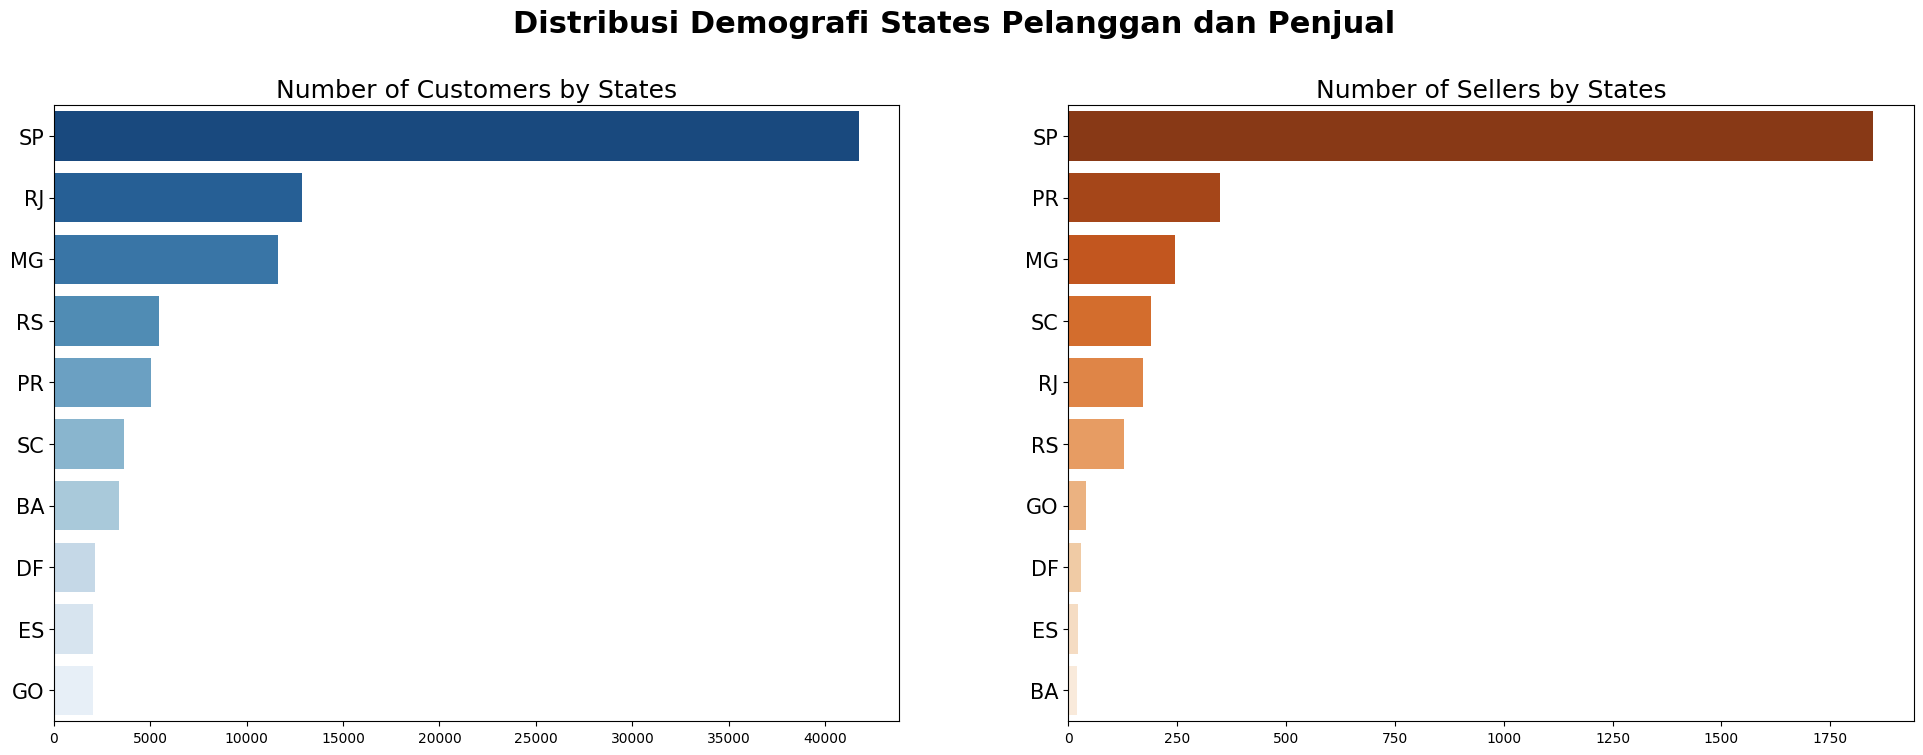

In [262]:
bystate_customers = customers_df.groupby("customer_state").customer_id.nunique().reset_index()
bystate_customers.rename(columns={
    "customer_id": "customer_count"
    }, inplace=True)
bystate_customers = bystate_customers.sort_values(by="customer_count", ascending=False).head(10)

bystate_sellers = sellers_df.groupby("seller_state").seller_id.nunique().reset_index()
bystate_sellers.rename(columns={
    "seller_id": "seller_count"
    }, inplace=True)
bystate_sellers = bystate_sellers.sort_values(by="seller_count", ascending=False).head(10)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 8))

sns.barplot(x="customer_count", y="customer_state", data=bystate_customers, ax=ax[0], palette="Blues_r")
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].set_title("Number of Customers by States", loc="center", fontsize=18)
ax[0].tick_params(axis='y', labelsize=15)

sns.barplot(x="seller_count", y="seller_state", data=bystate_sellers, ax=ax[1], palette="Oranges_r")
ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].set_title("Number of Sellers by States", loc="center", fontsize=18)
ax[1].tick_params(axis='y', labelsize=15)

plt.suptitle("Distribusi Demografi States Pelanggan dan Penjual", fontsize=22, fontweight='bold', y=1.0)
plt.show()

**Insight:**

- Visualisasi di atas memperlihatkan bahwa demografi e-commerce sangat terpusat di negara bagian SP (São Paulo), baik dari sisi suplai (Penjual) maupun demand (Pelanggan).
- Jumlah pelanggan di SP menyentuh angka lebih dari 40.000 pengguna, mengalahkan gabungan total pelanggan dari 4 negara bagian di bawahnya sekaligus.
- Keselarasan geografis antara mayoritas penjual dan pembeli ini merupakan metrik yang sangat sehat secara operasional bisnis, karena memfasilitasi rantai pasok (supply chain) yang lebih pendek, estimasi waktu tiba yang lebih cepat, dan biaya ongkos kirim yang lebih murah.

/tmp/ipykernel_508/435265969.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="customer_count", y="customer_city", data=bycity_customers, ax=ax[0], palette="Blues_r")
/tmp/ipykernel_508/435265969.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="seller_count", y="seller_city", data=bycity_sellers, ax=ax[1], palette="Oranges_r")


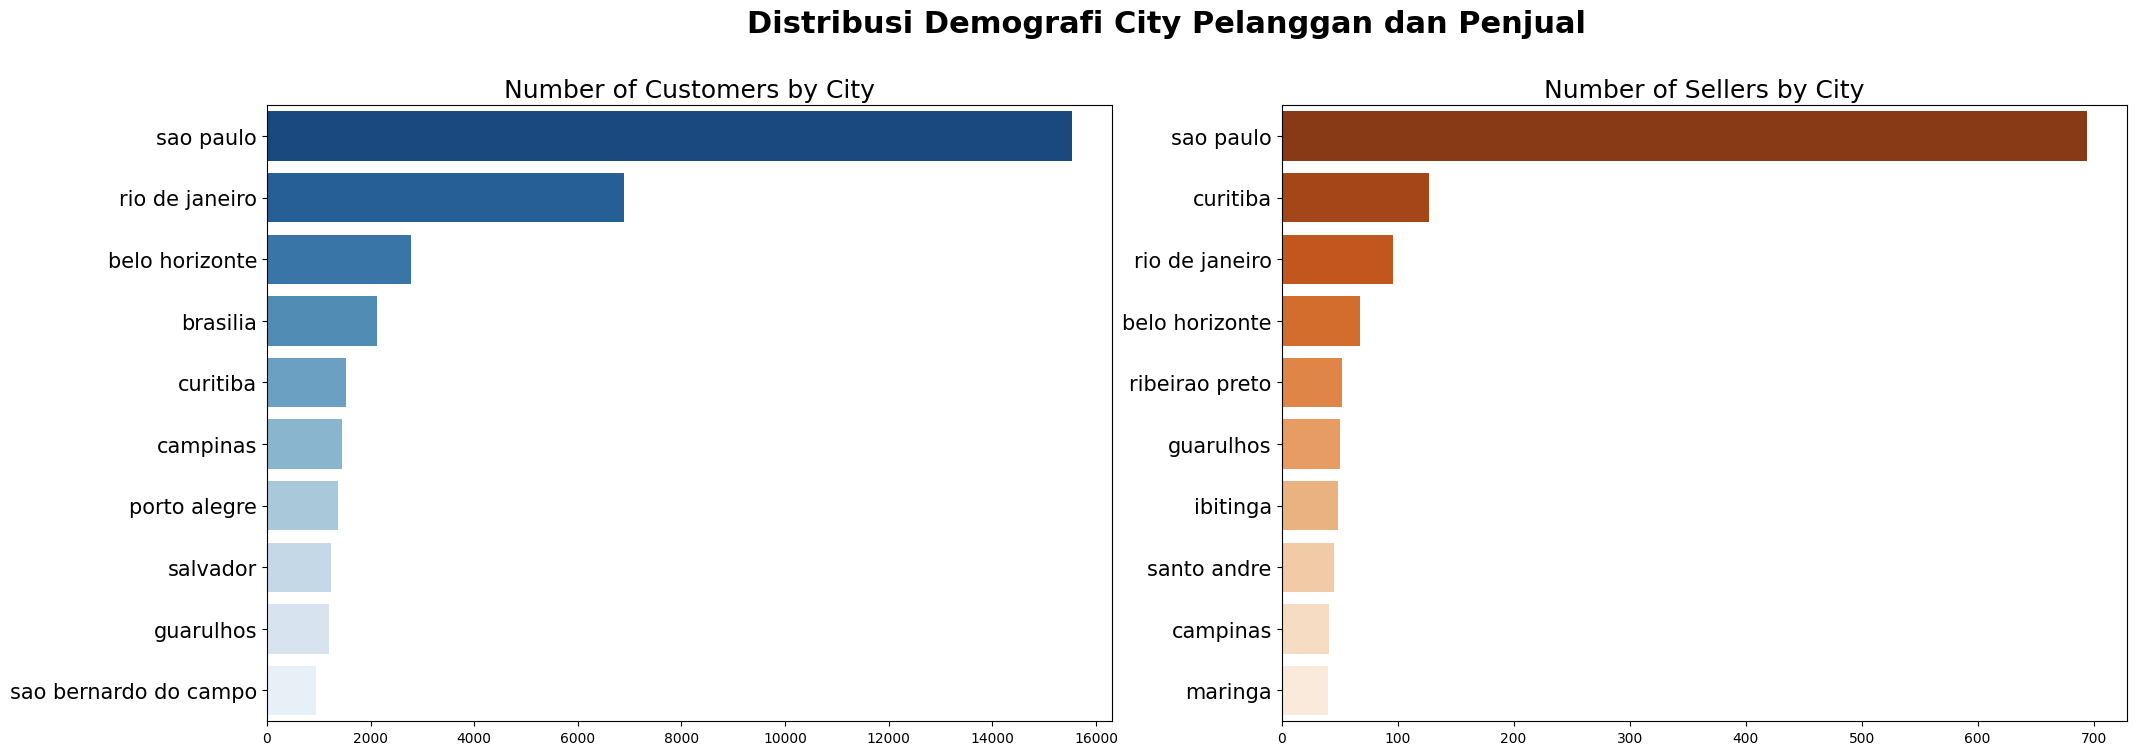

In [263]:
bycity_customers = customers_df.groupby("customer_city").customer_id.nunique().reset_index()
bycity_customers.rename(columns={
    "customer_id": "customer_count"
    }, inplace=True)
bycity_customers = bycity_customers.sort_values(by="customer_count", ascending=False).head(10)

bycity_sellers = sellers_df.groupby("seller_city").seller_id.nunique().reset_index()
bycity_sellers.rename(columns={
    "seller_id": "seller_count"
    }, inplace=True)
bycity_sellers = bycity_sellers.sort_values(by="seller_count", ascending=False).head(10)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 8))

sns.barplot(x="customer_count", y="customer_city", data=bycity_customers, ax=ax[0], palette="Blues_r")
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].set_title("Number of Customers by City", loc="center", fontsize=18)
ax[0].tick_params(axis='y', labelsize=15)

sns.barplot(x="seller_count", y="seller_city", data=bycity_sellers, ax=ax[1], palette="Oranges_r")
ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].set_title("Number of Sellers by City", loc="center", fontsize=18)
ax[1].tick_params(axis='y', labelsize=15)

plt.suptitle("Distribusi Demografi City Pelanggan dan Penjual", fontsize=22, fontweight='bold', y=1.0)
plt.show()

**Insight:**

- Visualisasi di atas memperlihatkan bahwa Kota são paulo tidak hanya mendominasi di tingkat negara bagian, tetapi juga menjadi kota pusat aktivitas ekonomi terbesar baik bagi pelanggan (lebih dari 15 ribu orang) maupun penjual (lebih dari 600 orang, mendekati 700).
- Pada sisi pelanggan, kota-kota besar seperti rio de janeiro dan belo horizonte mengikuti di posisi kedua dan ketiga. Namun pada sisi penjual, kota curitiba justru menempati posisi kedua, menunjukkan bahwa curitiba adalah hub penting bagi para penjual.
- Konsentrasi penjual yang tinggi di Kota são paulo dan curitiba (wilayah Selatan/Tenggara) sangat sinkron dengan lokasi mayoritas pelanggan. Hal ini menjelaskan mengapa ekosistem wilayah tersebut sangat kuat karena waktu pengiriman bisa ditekan seefisien mungkin.

### Pertanyaan 2:

Produk dan kategori apa yang memiliki volume penjualan tertinggi dan terendah?

/tmp/ipykernel_508/1783841746.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="total_sales", y="product_category_name", data=top_categories, ax=ax[0], palette="Greens_r")
/tmp/ipykernel_508/1783841746.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="total_sales", y="product_category_name", data=bottom_categories, ax=ax[1], palette="Reds_r")


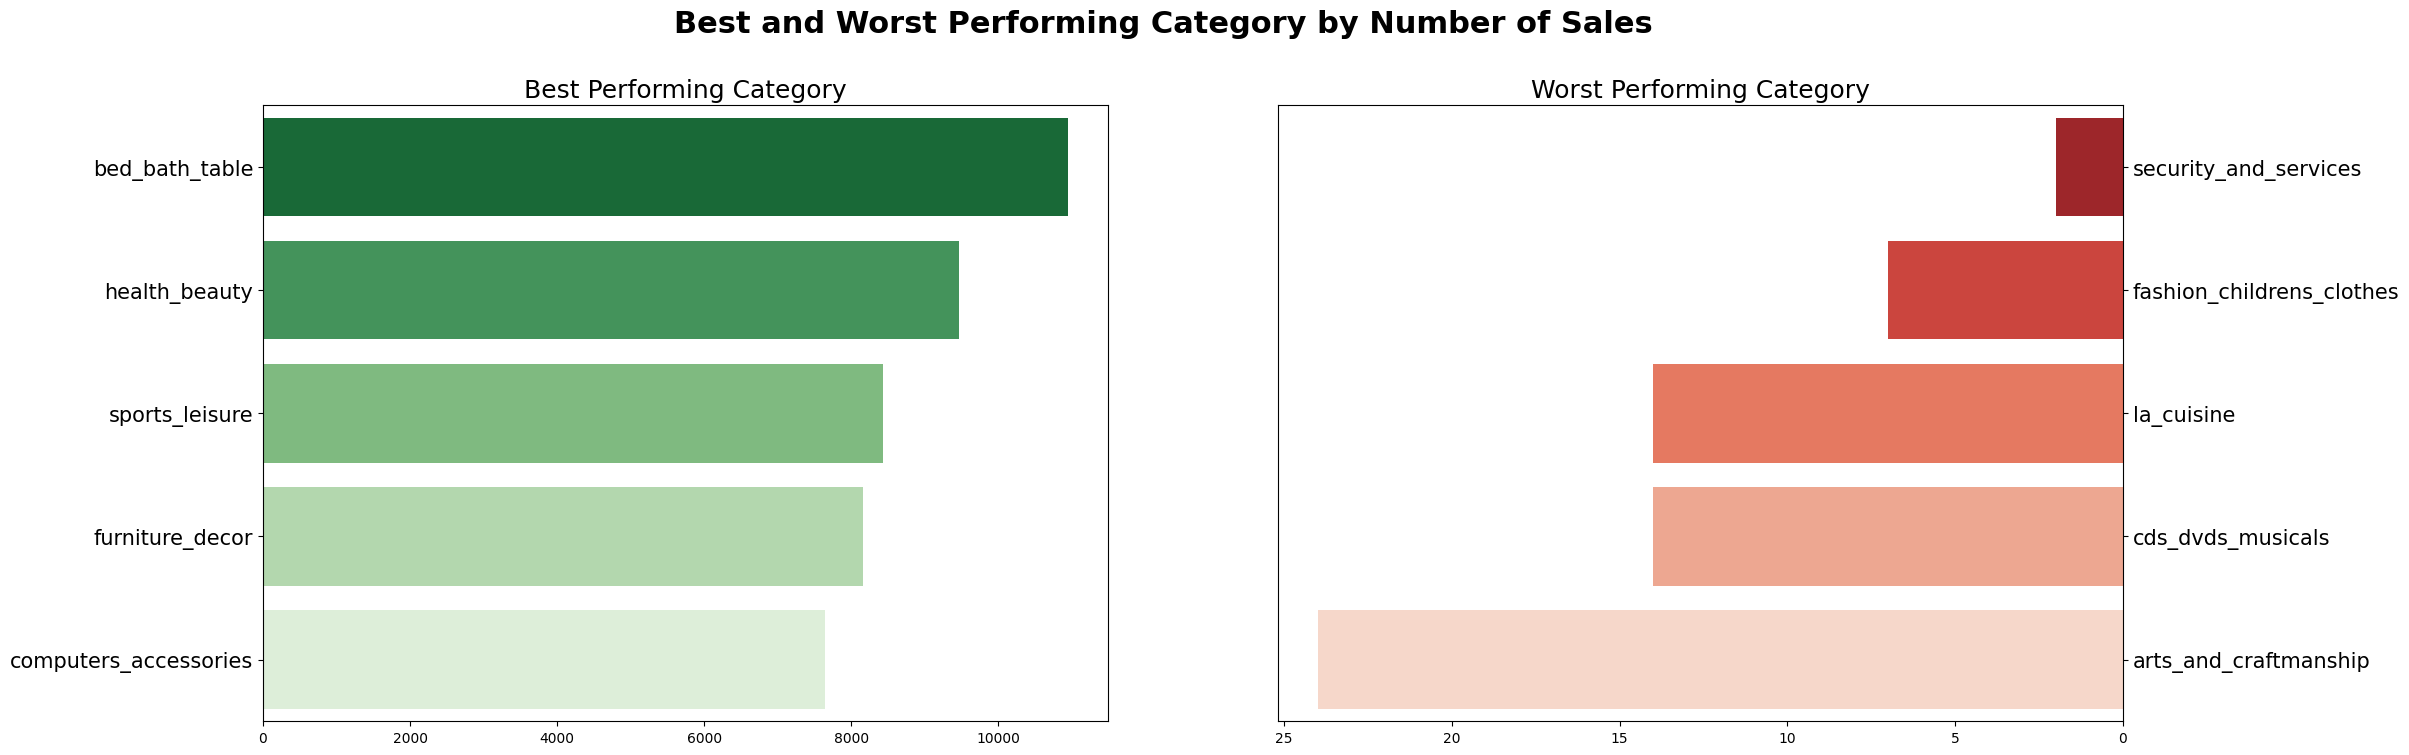

In [264]:
category_sales = final_sales_df.groupby('product_category_name').order_id.count().reset_index()
category_sales.rename(columns={'order_id': 'total_sales'}, inplace=True)

top_categories = category_sales.sort_values(by='total_sales', ascending=False).head(5)
bottom_categories = category_sales.sort_values(by='total_sales', ascending=True).head(5)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 8))

sns.barplot(x="total_sales", y="product_category_name", data=top_categories, ax=ax[0], palette="Greens_r")
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].set_title("Best Performing Category", loc="center", fontsize=18)
ax[0].tick_params(axis='y', labelsize=15)

sns.barplot(x="total_sales", y="product_category_name", data=bottom_categories, ax=ax[1], palette="Reds_r")
ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].invert_xaxis()
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].set_title("Worst Performing Category", loc="center", fontsize=18)
ax[1].tick_params(axis='y', labelsize=15)

plt.suptitle("Best and Worst Performing Category by Number of Sales", fontsize=22, fontweight='bold', y=1.0)
plt.show()

**Insight:**

- Kategori bed_bath_table menjadi penjualan tertinggi, menjadikannya volume terbesar dalam transaksi di e-commerce ini. Kategori lain seperti health_beauty dan sports_leisure juga menunjukkan performa yang sangat kuat di urutan lima tertinggi.
- Di sisi lain, kategori barang-barang spesifik seperti security_and_services dan fashion_childrens_clothes memiliki volume transaksi yang sangat minim (bahkan hanya menyentuh angka 1 digit penjualan).
- Tim marketing dapat menjadikan temuan ini sebagai dasar untuk membuat promosi bundling produk pada kategori terlaris, serta mengevaluasi kembali keberadaan  kategori-kategori terbawah di dalam katalog (apakah perlu diberikan diskon besar-besaran untuk menghabiskan stok, atau dihentikan pengadaannya).

/tmp/ipykernel_508/3752899014.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="total_sales", y="product_id", data=top_categories, ax=ax[0], palette="Greens_r")
/tmp/ipykernel_508/3752899014.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="total_sales", y="product_id", data=bottom_categories, ax=ax[1], palette="Reds_r")


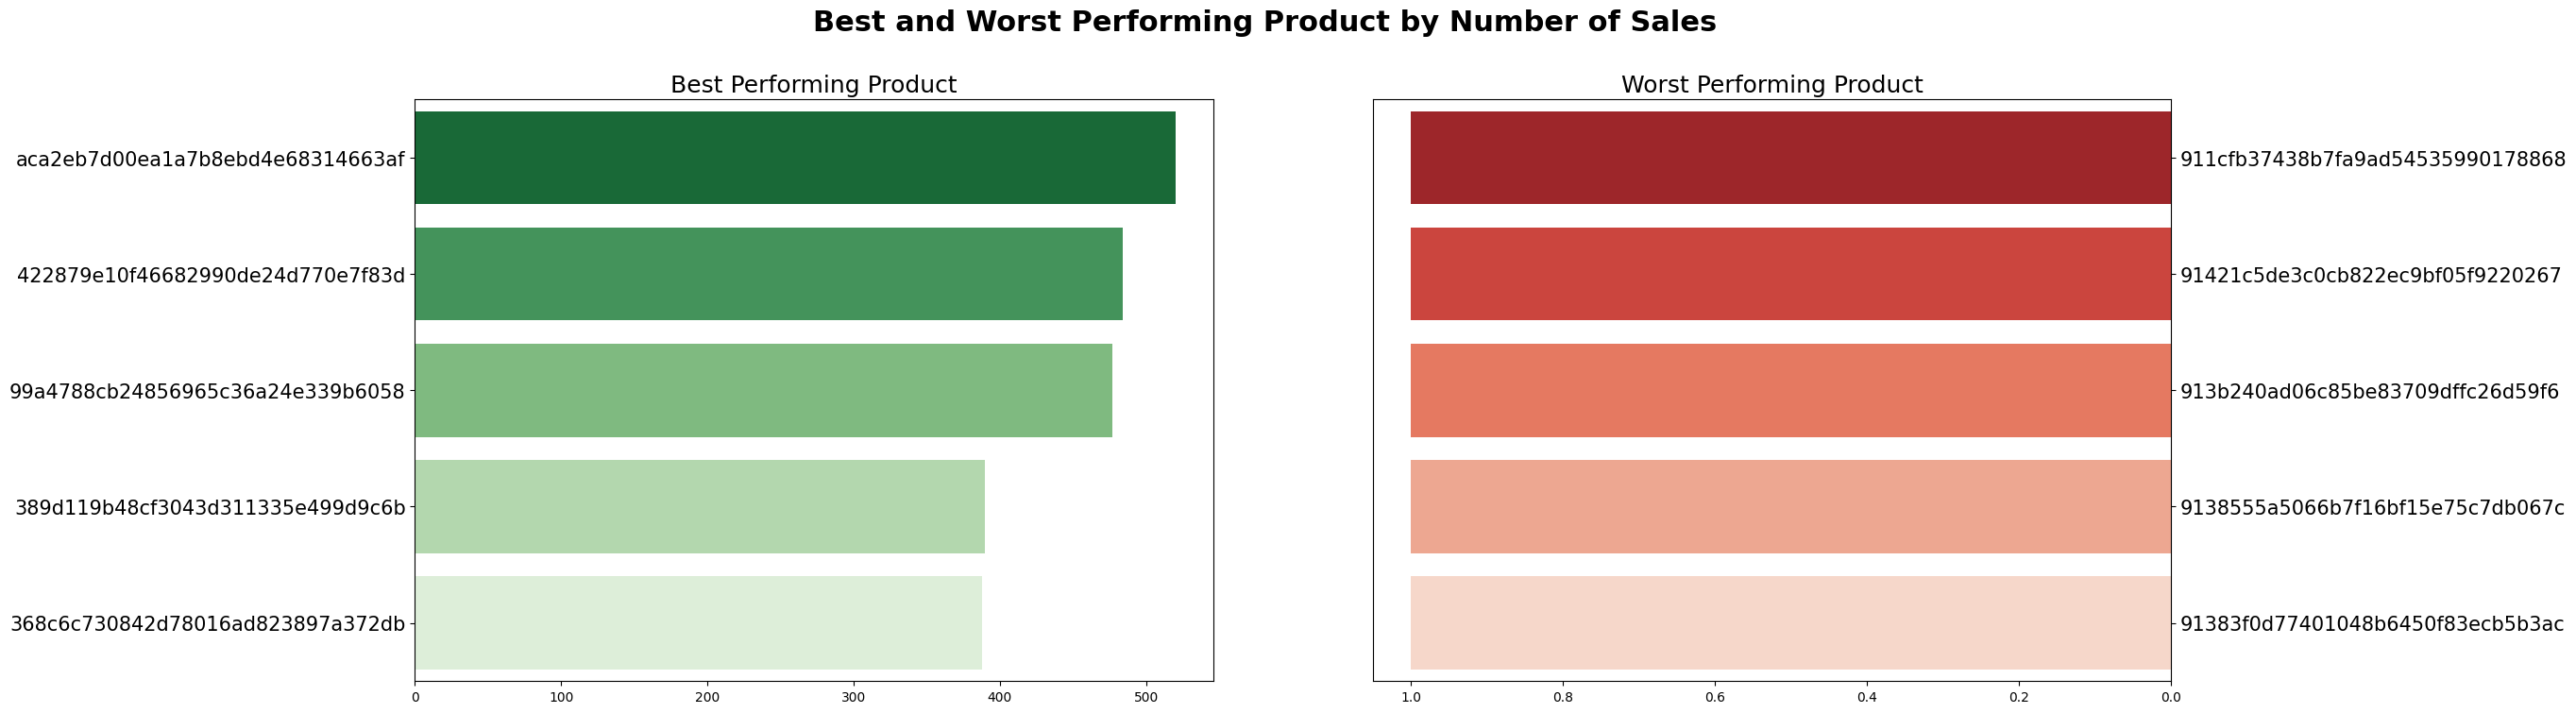

In [265]:
product_sales = final_sales_df.groupby('product_id').order_id.count().reset_index()
product_sales.rename(columns={'order_id': 'total_sales'}, inplace=True)

top_categories = product_sales.sort_values(by='total_sales', ascending=False).head(5)
bottom_categories = product_sales.sort_values(by='total_sales', ascending=True).head(5)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 8))

sns.barplot(x="total_sales", y="product_id", data=top_categories, ax=ax[0], palette="Greens_r")
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].set_title("Best Performing Product", loc="center", fontsize=18)
ax[0].tick_params(axis='y', labelsize=15)

sns.barplot(x="total_sales", y="product_id", data=bottom_categories, ax=ax[1], palette="Reds_r")
ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].invert_xaxis()
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].set_title("Worst Performing Product", loc="center", fontsize=18)
ax[1].tick_params(axis='y', labelsize=15)

plt.suptitle("Best and Worst Performing Product by Number of Sales", fontsize=22, fontweight='bold', y=1.0)
plt.show()

**Insight:**

- Pada product, visualisasi menunjukkan adanya satu produk spesifik (dengan ID awalan aca2eb7d...) yang mencatatkan angka penjualan sangat tinggi. Hal ini membuktikan bahwa meskipun suatu kategori laris, volume penjualannya bisa jadi ditopang secara masif oleh satu atau dua barang favorit saja.
- Di sisi lain, terdapat produk-produk (seperti ID 911cfb37...) yang frekuensi terjualnya sangat minim (berada di angka terbawah). Dalam operasional gudang, barang-barang ini rentan menjadi dead stock (stok mati).
- Tim Supply Chain wajib memasukkan produk favorit dalam daftar prioritas restock untuk mencegah kekosongan barang (out-of-stock). Sebaliknya, produk dengan performa terburuk perlu dievaluasi keberadaannya di gudang, misalnya dengan melakukan program cuci gudang untuk mengurangi beban biaya penyimpanan.

## Analisis Lanjutan (Opsional)

Seberapa sering seorang pelanggan melakukan pembelian dalam beberapa bulan terakhir?

In [266]:
rfm_merge = pd.merge(
    left=delivered_items_df,
    right=customers_df,
    how="left",
    left_on="customer_id",
    right_on="customer_id"
)

recent_date = rfm_merge['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm_df = rfm_merge.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (recent_date - x.max()).days, # Recency
    'order_id': 'nunique', # Frequency
    'price': 'sum' # Monetary
}).reset_index()

rfm_df.rename(columns={
    'order_purchase_timestamp': 'recency',
    'order_id': 'frequency',
    'price': 'monetary'
}, inplace=True)

rfm_df.head()

,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90
2,0000f46a3911fa3c0805444483337064,537,1,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99
4,0004aac84e0df4da2b147fca70cf8255,288,1,180.00


**Insight:**

Karena data ini adalah data historis (tahun 2018), kita harus men set "tanggal hari ini" (current date) menjadi satu hari setelah transaksi terakhir yang terekam di dalam dataset.

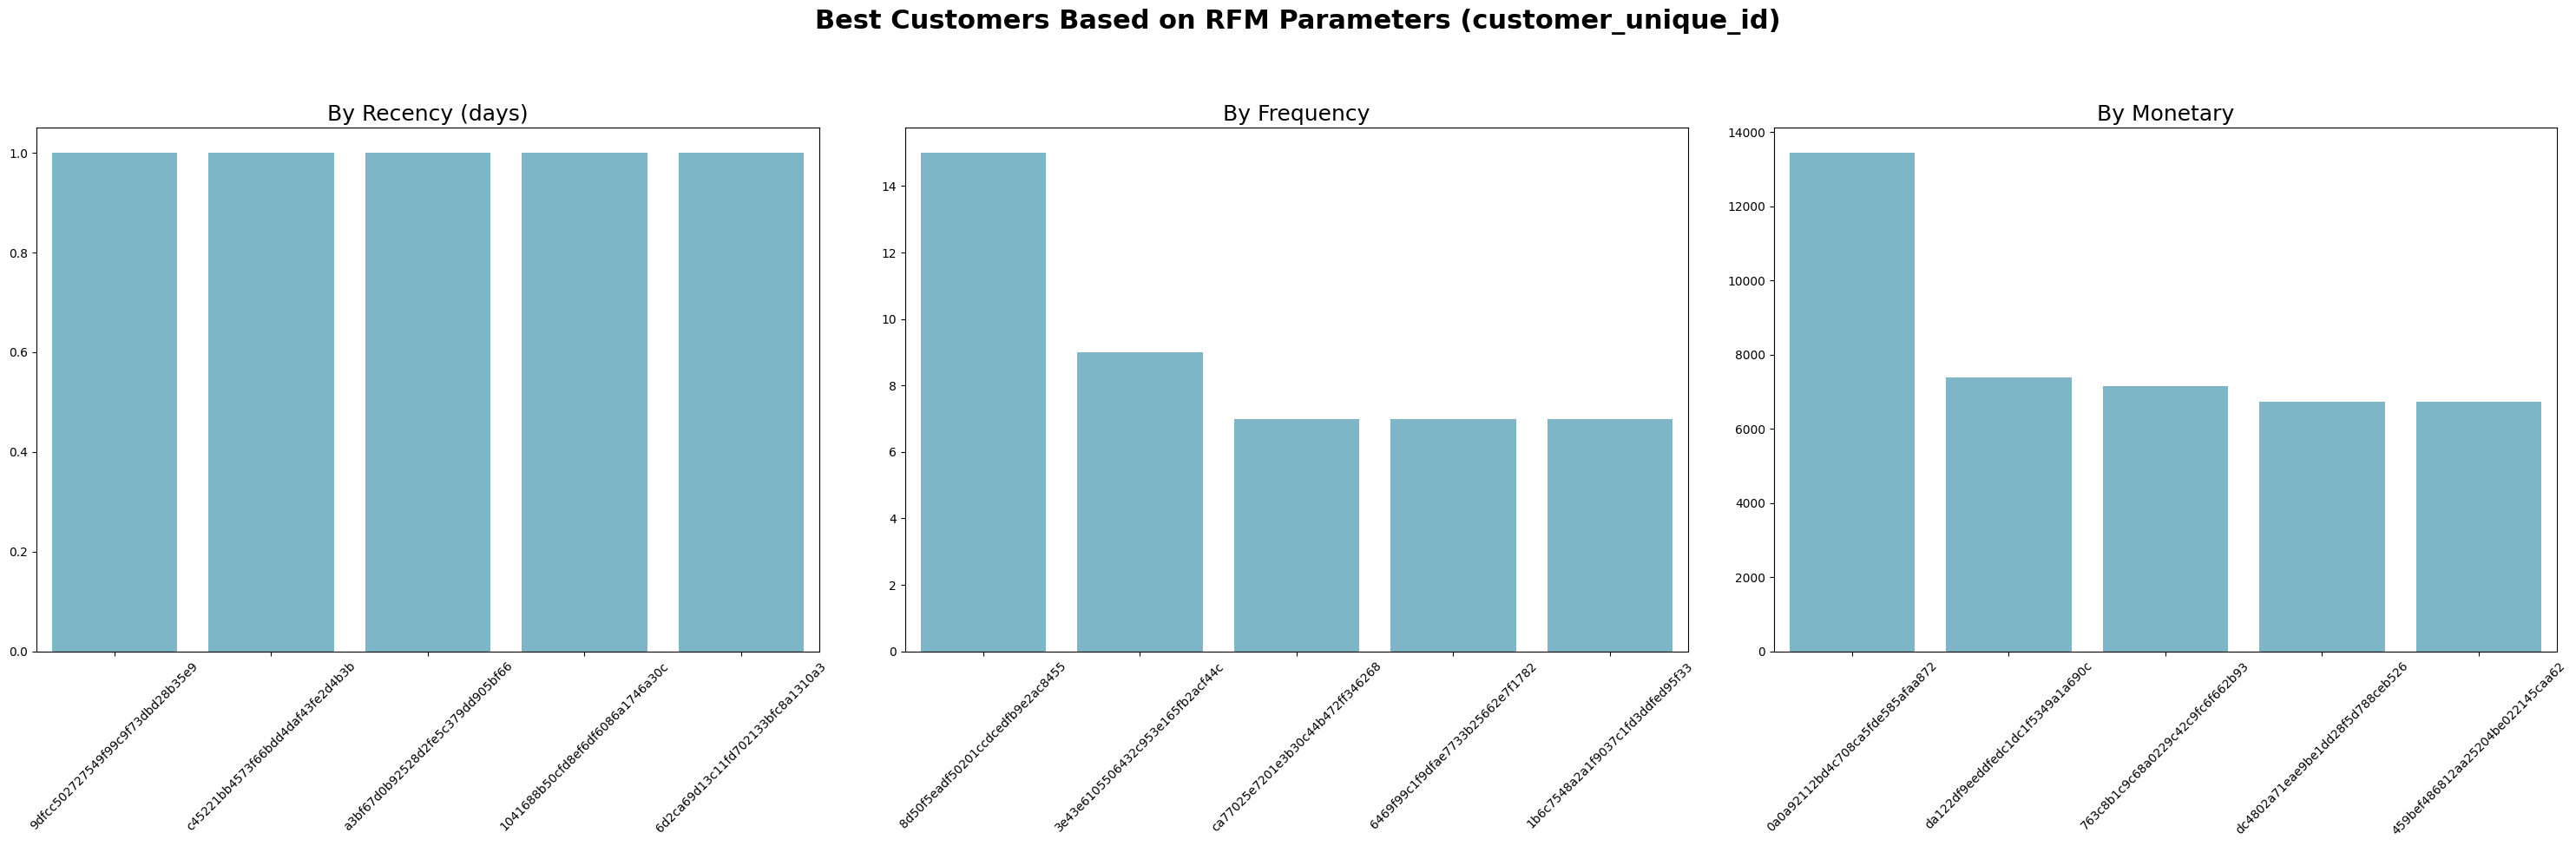

In [267]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 10))

colors = ["#72BCD4", "#72BCD4", "#72BCD4", "#72BCD4", "#72BCD4"]

sns.barplot(y="recency", x="customer_unique_id", data=rfm_df.sort_values(by="recency", ascending=True).head(5), palette=colors, ax=ax[0], hue="customer_unique_id", legend=False)
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].set_title("By Recency (days)", loc="center", fontsize=18)
ax[0].tick_params(axis='x', labelsize=10, rotation=45)

sns.barplot(y="frequency", x="customer_unique_id", data=rfm_df.sort_values(by="frequency", ascending=False).head(5), palette=colors, ax=ax[1], hue="customer_unique_id", legend=False)
ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].set_title("By Frequency", loc="center", fontsize=18)
ax[1].tick_params(axis='x', labelsize=10, rotation=45)

sns.barplot(y="monetary", x="customer_unique_id", data=rfm_df.sort_values(by="monetary", ascending=False).head(5), palette=colors, ax=ax[2], hue="customer_unique_id", legend=False)
ax[2].set_ylabel(None)
ax[2].set_xlabel(None)
ax[2].set_title("By Monetary", loc="center", fontsize=18)
ax[2].tick_params(axis='x', labelsize=10, rotation=45)

plt.suptitle("Best Customers Based on RFM Parameters (customer_unique_id)", fontsize=22, fontweight='bold', y=1.0)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Insight:**

- Visualisasi di atas menunjukkan terdapat 5 pelanggan (top 5 unique IDs) yang baru saja melakukan transaksi tepat 1 hari sebelum dataset ini dipotong/diambil. Pelanggan dengan recency rendah ini adalah target yang paling responsif untuk diberikan kampanye promosi lanjutan (misal: voucher diskon pembelian kedua).
- Menjawab pertanyaan bisnis terkait seberapa sering pelanggan berbelanja, data memperlihatkan bahwa mayoritas pelanggan adalah pelanggan sekali-beli (one-time buyer). Namun, analisis ini berhasil mengisolasi satu "Sultan" pelanggan paling setia (dengan awalan ID 8d50f5...) yang melakukan pembelian hingga 16 kali transaksi berbeda. Ini adalah anomali positif yang menunjukkan adanya basis returning customer.
- Dari sisi pendapatan, terdapat pelanggan yang menyumbang pemasukan sangat besar secara individu, dengan total transaksi mencapai lebih dari $13.000.

- Kesimpulan
  
  Pelanggan yang menempati peringkat tertinggi pada metrik Frequency dan Monetary adalah "VIP Customers". E-commerce dapat menerapkan program loyalitas (seperti bebas ongkos kirim eksklusif atau hadiah poin) khusus untuk ID pelanggan tersebut guna menjaga retensi mereka agar tidak berpindah ke kompetitor.

## Conclusion

- Conclution pertanyaan 1 (Demografi Pelanggan & Penjual)
  
  Demografi ekosistem e-commerce sangat tersentralisasi di wilayah bagian tenggara Brazil. Negara bagian SP (São Paulo) dan kota são paulo mendominasi  sebagai penyumbang pelanggan dan penjual terbanyak. Keselarasan geografis antara pusat demand (pelanggan) dan pusat supply (penjual) ini menciptakan ekosistem yang sangat efisien secara logistik, memungkinkan biaya ongkos kirim yang lebih rendah dan durasi pengiriman yang lebih cepat untuk mayoritas transaksi.

- Conclution pertanyaan 2 (Performa Kategori & Produk)
  
  Kategori bed_bath_table merupakan penyumbang volume penjualan tertinggi, menunjukkan tingginya minat pasar pada produk gaya hidup dan perabotan rumah. Sebaliknya, kategori seperti security_and_services memiliki performa penjualan terburuk. Dari sisi operasional mikro, ditemukan juga fenomena di mana ID produk tertentu menyumbang ratusan transaksi sendirian, menegaskan pentingnya prioritas restock pada barang-barang spesifik tersebut agar terhindar dari out-of-stock.

- Conclution pertanyaan 3 (RFM Analysis & Perilaku Pelanggan)

  Berdasarkan analisis RFM (Recency, Frequency, Monetary), diketahui bahwa mayoritas pengguna platform adalah pelanggan sekali-beli (one-time buyer). Namun, platform ini memiliki segmen "VIP Customers", yaitu pelanggan dengan tingkat frekuensi belanja yang tinggi (hingga 16 kali transaksi) dan nilai pengeluaran total (Monetary) yang masif. Rekomendasi strategis untuk e-commerce adalah merancang program loyalitas eksklusif (seperti poin reward atau gratis ongkir eksklusif) untuk menjaga retensi pelanggan bernilai tinggi ini agar tidak beralih ke kompetitor.

In [268]:
# main_data.csv
all_data_df = pd.merge(
    left=final_sales_df,
    right=customers_df,
    how="left",
    left_on="customer_id",
    right_on="customer_id"
)

all_data_df = pd.merge(
    left=all_data_df,
    right=sellers_df,
    how="left",
    left_on="seller_id",
    right_on="seller_id"
)

all_data_df.to_csv("main_data.csv", index=False)

rfm_df.to_csv("rfm_data.csv", index=False)